# CIFAR-10 Transfer Learning (TensorFlow / Keras)
## Phase 2: ResNet50V2 | Phase 3: EfficientNetB0
- Loads preprocessed 32×32 data from `cifar10_preprocessed.npz`
- On-the-fly resize to 224×224 using `tf.image.resize`
- **Phase 2:** ResNet50V2 pretrained on ImageNet → Fine-tune
- **Phase 3:** EfficientNetB0 pretrained on ImageNet → Fine-tune
- Strategy: Freeze backbone → Train head → Unfreeze → Fine-tune all

> Note: TensorFlow/Keras does not include ResNet18. We use ResNet50V2 as the closest standard alternative.

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import time

if os.path.basename(os.getcwd()) == 'Model':
    os.chdir('..')
if os.path.basename(os.getcwd()) == 'TensorFlow':
    os.chdir('..')

## 0. Setup Colab Environment

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')

# Define a base path for saving models and figures in Google Drive
# This assumes a 'TensorFlow' folder exists or will be created in your Drive
BASE_PATH = '/content/drive/MyDrive/TensorFlow'

# Create directories if they don't exist
model_dir = os.path.join(BASE_PATH, 'Model')
figure_dir = os.path.join(BASE_PATH, 'Figure')
preprocessing_dir = os.path.join(BASE_PATH, 'Preprocessing') # Added this line

os.makedirs(model_dir, exist_ok=True)
os.makedirs(figure_dir, exist_ok=True)
os.makedirs(preprocessing_dir, exist_ok=True) # Added this line

print(f"Saving models to: {model_dir}")
print(f"Saving figures to: {figure_dir}")
print(f"Preprocessing data expected in: {preprocessing_dir}") # Added this line

# Adjust the data loading path to be relative to BASE_PATH
data_path = os.path.join(preprocessing_dir, 'cifar10_preprocessed.npz')
if not os.path.exists(data_path):
    print(f"Warning: Data file not found at '{data_path}'. Please ensure it's accessible.")

Mounted at /content/drive
Saving models to: /content/drive/MyDrive/TensorFlow/Model
Saving figures to: /content/drive/MyDrive/TensorFlow/Figure
Preprocessing data expected in: /content/drive/MyDrive/TensorFlow/Preprocessing


## 1. Setup Device

In [3]:
print(f'TensorFlow version: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')
print(f'Built with CUDA: {tf.test.is_built_with_cuda()}')

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


## 2. Load Data + Build tf.data Pipeline with On-the-fly Resize

In [4]:
import os
print(f"Checking for file existence at: {data_path}")
if not os.path.exists(data_path):
    print("Error: File still not found at the specified path.")
else:
    print("File found. Attempting to load...")

data = np.load(data_path)

X_train = data['X_train'].astype(np.float32)
X_val   = data['X_val'].astype(np.float32)
X_test  = data['X_test'].astype(np.float32)
y_train = data['y_train'].astype(np.int64)
y_val   = data['y_val'].astype(np.int64)
y_test  = data['y_test'].astype(np.int64)
label_names = list(data['label_names'])

# Reverse CIFAR standardization (pretrained models expect their own preprocessing)
cifar_mean = data['channel_mean']; cifar_std = data['channel_std']
X_train = X_train * cifar_std + cifar_mean
X_val   = X_val   * cifar_std + cifar_mean
X_test  = X_test  * cifar_std + cifar_mean

# Scale back to 0-255 range for Keras preprocessing functions
X_train = np.clip(X_train * 255.0, 0, 255).astype(np.float32)
X_val   = np.clip(X_val   * 255.0, 0, 255).astype(np.float32)
X_test  = np.clip(X_test  * 255.0, 0, 255).astype(np.float32)

print(f'Loaded: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}')

Checking for file existence at: /content/drive/MyDrive/TensorFlow/Preprocessing/cifar10_preprocessed.npz
File found. Attempting to load...
Loaded: X_train=(67500, 32, 32, 3), X_val=(7500, 32, 32, 3), X_test=(10000, 32, 32, 3)


### Verify Data File Path

In [5]:
BATCH_SIZE = 64

def make_dataset(images, labels, preprocess_fn, shuffle=False):
    def preprocess(img, label):
        img = tf.image.resize(img, (224, 224))
        img = preprocess_fn(img)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        ds = ds.shuffle(10000)
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

print(f'Batch size: {BATCH_SIZE}')

Batch size: 64


## 3. Helper Functions

In [6]:
def evaluate_model(model, test_ds, y_test, label_names):
    y_pred = model.predict(test_ds, verbose=0).argmax(axis=1)
    y_true = y_test
    test_acc = (y_pred == y_true).mean()

    print(f'Test Accuracy: {test_acc*100:.2f}%')
    print(f'\nPer-Class Accuracy:')
    print('-' * 30)
    for i, name in enumerate(label_names):
        mask = y_true == i
        if mask.sum() > 0:
            acc = (y_pred[mask] == i).mean()
            print(f'  {name:<12s}: {acc*100:.1f}%')
    print(f'\n{classification_report(y_true, y_pred, target_names=label_names)}')
    return y_pred, y_true, test_acc


def plot_results(history_dict, y_pred, y_true, test_acc, label_names, model_name, save_prefix):
    epochs_range = range(1, len(history_dict['loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs_range, history_dict['loss'], 'b-', label='Train Loss', alpha=0.8)
    ax1.plot(epochs_range, history_dict['val_loss'], 'r-', label='Val Loss', alpha=0.8)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_range, history_dict['accuracy'], 'b-', label='Train Acc', alpha=0.8)
    ax2.plot(epochs_range, history_dict['val_accuracy'], 'r-', label='Val Acc', alpha=0.8)
    ax2.axhline(y=test_acc, color='green', linestyle='--', label=f'Test: {test_acc*100:.2f}%')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} — Test: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(figure_dir, f'{save_prefix}_curves.png'), dpi=150)
    plt.show()

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(label_names, rotation=45, ha='right'); ax.set_yticklabels(label_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{model_name} — Test: {test_acc*100:.2f}%')
    for i in range(10):
        for j in range(10):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=9)
    plt.colorbar(im); plt.tight_layout()
    plt.savefig(os.path.join(figure_dir, f'{save_prefix}_confusion.png'), dpi=150)
    plt.show()


def merge_histories(h1, h2):
    merged = {}
    for key in h1:
        merged[key] = h1[key] + h2[key]
    return merged

---
# Phase 2: ResNet50V2 (Transfer Learning)

**Strategy:**
1. Load ResNet50V2 pretrained on ImageNet
2. **Freeze** all backbone layers (keep ImageNet knowledge)
3. Add new classification head: GlobalAveragePooling → Dropout → Dense(10)
4. Train only the new head for 10 epochs (fast)
5. **Unfreeze** entire model
6. Fine-tune all layers with small LR for 20 epochs

## Phase 2.1: Build ResNet50V2 + Create Datasets

In [ ]:
# Build datasets with ResNet50V2 preprocessing
resnet_preprocess = keras.applications.resnet_v2.preprocess_input

train_ds_resnet = make_dataset(X_train, y_train, resnet_preprocess, shuffle=True)
val_ds_resnet   = make_dataset(X_val,   y_val,   resnet_preprocess)
test_ds_resnet  = make_dataset(X_test,  y_test,  resnet_preprocess)

# Build model
base_resnet = keras.applications.ResNet50V2(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
base_resnet.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = base_resnet(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)
resnet_model = keras.Model(inputs, outputs)

total_params = resnet_model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in resnet_model.trainable_weights)
frozen_params = total_params - trainable_params
print(f'Total params:     {total_params:,}')
print(f'Frozen params:    {frozen_params:,}')
print(f'Trainable params: {trainable_params:,} (only the new head)')

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Total params:     23,585,290
Frozen params:    23,564,800
Trainable params: 20,490 (only the new head)


## Phase 2.2: Train Head Only (Frozen Backbone) — 10 Epochs

In [ ]:
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print('=== Phase 2.2: Training HEAD only (backbone frozen) ===')
start = time.time()
history_head = resnet_model.fit(
    train_ds_resnet,
    epochs=10,
    validation_data=val_ds_resnet,
    verbose=1
)
print(f'Completed in {time.time()-start:.1f}s')

resnet_model.save(os.path.join(model_dir, 'best_resnet_head.h5'))

=== Phase 2.2: Training HEAD only (backbone frozen) ===
Epoch 1/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 636s 547ms/step - accuracy: 0.7605 - loss: 0.6993 - val_accuracy: 0.7213 - val_loss: 0.8824
Epoch 2/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 544s 516ms/step - accuracy: 0.8527 - loss: 0.4301 - val_accuracy: 0.8204 - val_loss: 0.5293
Epoch 3/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 543s 515ms/step - accuracy: 0.8897 - loss: 0.3174 - val_accuracy: 0.8463 - val_loss: 0.4656
Epoch 4/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 544s 515ms/step - accuracy: 0.9162 - loss: 0.2430 - val_accuracy: 0.8276 - val_loss: 0.5105
Epoch 5/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 543s 515ms/step - accuracy: 0.9355 - loss: 0.1866 - val_accuracy: 0.8543 - val_loss: 0.4970
Epoch 6/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 543s 515ms/step - accuracy: 0.9487 - loss: 0.1449 - val_accuracy: 0.8729 - val_loss: 0.4256
Epoch 7/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 543s 514ms/step - accuracy: 0.9576 - loss: 0.1209 - val_accuracy: 0.8731 - val_loss: 0.4917
Epoch 

Completed in 5546.9s


## Phase 2.3: Unfreeze + Fine-tune All Layers — 20 Epochs

In [ ]:
base_resnet.trainable = True

resnet_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks_resnet = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(model_dir, 'best_resnet_finetuned.h5'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

print('=== Phase 2.3: Fine-tuning ALL layers ===')
start = time.time()
history_ft = resnet_model.fit(
    train_ds_resnet,
    epochs=20,
    validation_data=val_ds_resnet,
    callbacks=callbacks_resnet,
    verbose=1
)
print(f'Completed in {time.time()-start:.1f}s')

=== Phase 2.3: Fine-tuning ALL layers ===
Epoch 1/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.7015 - loss: 0.8677
Epoch 1: val_accuracy improved from None to 0.91000, saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5



Epoch 1: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 603s 521ms/step - accuracy: 0.8247 - loss: 0.5160 - val_accuracy: 0.9100 - val_loss: 0.2588
Epoch 2/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9366 - loss: 0.1905
Epoch 2: val_accuracy improved from 0.91000 to 0.92733, saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5



Epoch 2: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 528s 500ms/step - accuracy: 0.9496 - loss: 0.1526 - val_accuracy: 0.9273 - val_loss: 0.2203
Epoch 3/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.9762 - loss: 0.0720
Epoch 3: val_accuracy improved from 0.92733 to 0.93040, saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5



Epoch 3: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 526s 498ms/step - accuracy: 0.9818 - loss: 0.0564 - val_accuracy: 0.9304 - val_loss: 0.2368
Epoch 4/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9908 - loss: 0.0300
Epoch 4: val_accuracy improved from 0.93040 to 0.93787, saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5



Epoch 4: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 530s 503ms/step - accuracy: 0.9913 - loss: 0.0285 - val_accuracy: 0.9379 - val_loss: 0.2216
Epoch 5/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9952 - loss: 0.0168
Epoch 5: val_accuracy improved from 0.93787 to 0.93827, saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5


...


Epoch 6: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 526s 499ms/step - accuracy: 0.9965 - loss: 0.0116 - val_accuracy: 0.9420 - val_loss: 0.2230
Epoch 7/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9980 - loss: 0.0082
Epoch 7: val_accuracy did not improve from 0.94200
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 523s 496ms/step - accuracy: 0.9979 - loss: 0.0080 - val_accuracy: 0.9415 - val_loss: 0.2332
Epoch 8/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9988 - loss: 0.0056
Epoch 8: val_accuracy did not improve from 0.94200
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 524s 496ms/step - accuracy: 0.9987 - loss: 0.0056 - val_accuracy: 0.9405 - val_loss: 0.2304
Epoch 9/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9987 - loss: 0.0050
Epoch 9: val_accuracy did not improve from 0.94200
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 524s 496ms/step - accuracy: 0.9987 - loss: 0.0048 - val_accuracy: 0.9413 - va


Epoch 10: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 530s 503ms/step - accuracy: 0.9986 - loss: 0.0050 - val_accuracy: 0.9437 - val_loss: 0.2537
Epoch 11/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.9988 - loss: 0.0040
Epoch 11: val_accuracy did not improve from 0.94373
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 521s 494ms/step - accuracy: 0.9988 - loss: 0.0044 - val_accuracy: 0.9436 - val_loss: 0.2527
Epoch 12/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9990 - loss: 0.0040
Epoch 12: val_accuracy did not improve from 0.94373
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 525s 498ms/step - accuracy: 0.9990 - loss: 0.0041 - val_accuracy: 0.9421 - val_loss: 0.2527
Epoch 13/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9991 - loss: 0.0035
Epoch 13: val_accuracy did not improve from 0.94373
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 526s 498ms/step - accuracy: 0.9991 - loss: 0.0034 - val_accuracy: 0.94


Epoch 14: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 533s 505ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9456 - val_loss: 0.2511
Epoch 15/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9998 - loss: 0.0016
Epoch 15: val_accuracy did not improve from 0.94560
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 526s 498ms/step - accuracy: 0.9997 - loss: 0.0016 - val_accuracy: 0.9436 - val_loss: 0.2552
Epoch 16/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9998 - loss: 0.0014
Epoch 16: val_accuracy improved from 0.94560 to 0.94733, saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5



Epoch 16: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 532s 505ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 0.9473 - val_loss: 0.2426
Epoch 17/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9996 - loss: 0.0016
Epoch 17: val_accuracy did not improve from 0.94733
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 530s 503ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9436 - val_loss: 0.2472
Epoch 18/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9996 - loss: 0.0018
Epoch 18: val_accuracy did not improve from 0.94733
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 526s 498ms/step - accuracy: 0.9997 - loss: 0.0016 - val_accuracy: 0.9453 - val_loss: 0.2564
Epoch 19/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9998 - loss: 0.0014
Epoch 19: val_accuracy did not improve from 0.94733
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 526s 498ms/step - accuracy: 0.9998 - loss: 0.0014 - val_accuracy: 0.94


Epoch 20: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_resnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 537s 509ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9479 - val_loss: 0.2465
Restoring model weights from the end of the best epoch: 20.
Completed in 10625.7s


## Phase 2.4: ResNet50V2 Test Evaluation

=== ResNet50V2 Test Results ===
Test Accuracy: 94.30%

Per-Class Accuracy:
------------------------------
  airplane    : 96.4%
  automobile  : 97.1%
  bird        : 92.9%
  cat         : 89.1%
  deer        : 93.1%
  dog         : 89.2%
  frog        : 97.6%
  horse       : 94.9%
  ship        : 97.1%
  truck       : 95.6%

              precision    recall  f1-score   support

    airplane       0.95      0.96      0.95      1000
  automobile       0.96      0.97      0.97      1000
        bird       0.95      0.93      0.94      1000
         cat       0.88      0.89      0.89      1000
        deer       0.94      0.93      0.93      1000
         dog       0.92      0.89      0.90      1000
        frog       0.95      0.98      0.96      1000
       horse       0.96      0.95      0.96      1000
        ship       0.96      0.97      0.97      1000
       truck       0.96      0.96      0.96      1000

    accuracy                           0.94     10000
   macro avg       0.94

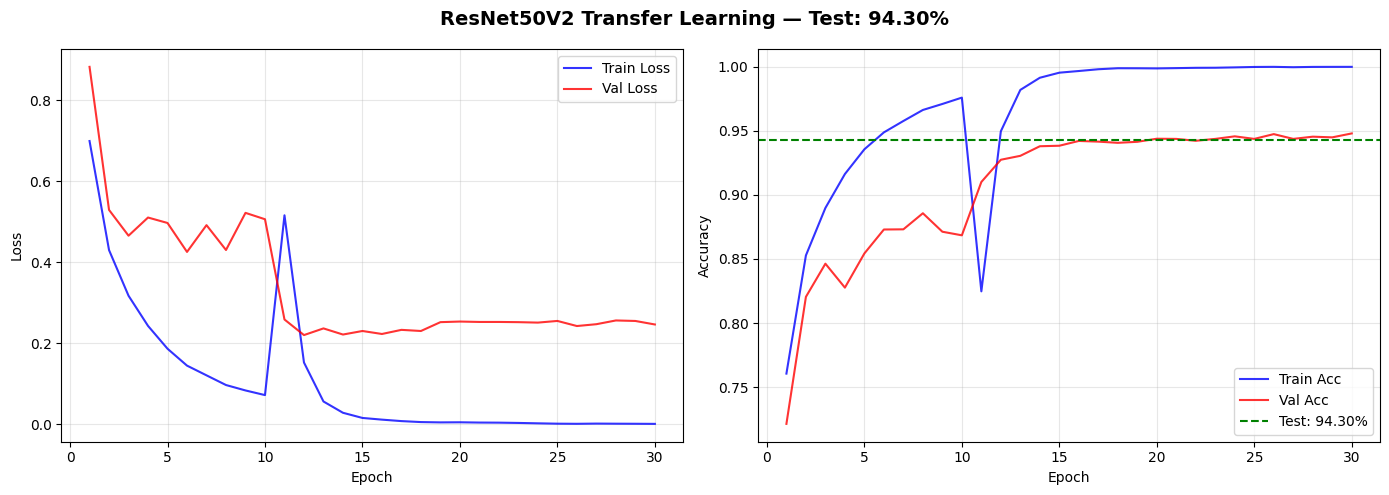

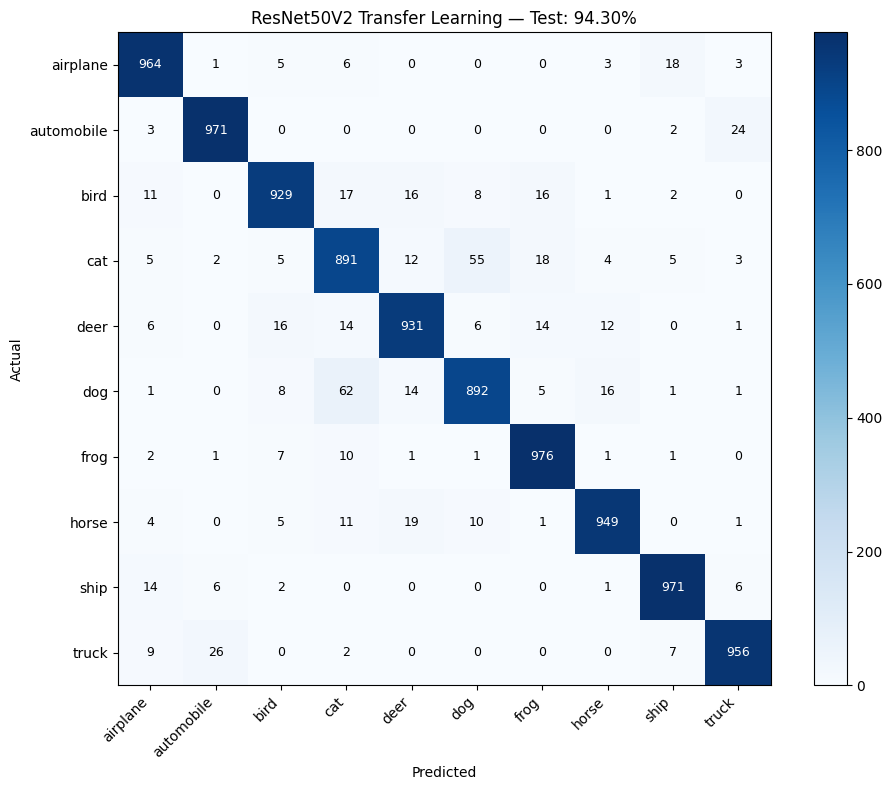

In [ ]:
resnet_model = keras.models.load_model(os.path.join(model_dir, 'best_resnet_finetuned.h5'))

print('=== ResNet50V2 Test Results ===')
resnet_pred, resnet_true, resnet_test_acc = evaluate_model(
    resnet_model, test_ds_resnet, y_test, label_names
)

resnet_history = merge_histories(history_head.history, history_ft.history)
plot_results(resnet_history, resnet_pred, resnet_true, resnet_test_acc,
             label_names, 'ResNet50V2 Transfer Learning', 'resnet')

---
# Phase 3: EfficientNetB0 (Transfer Learning)

**Why EfficientNet?**
- More efficient than ResNet (fewer params, better accuracy)
- Uses compound scaling (depth + width + resolution)
- EfficientNet-B0 is the smallest variant — fast to train

**Same strategy:**
1. Freeze backbone → Train head (10 epochs)
2. Unfreeze → Fine-tune all (20 epochs)

## Phase 3.1: Build EfficientNetB0 + Create Datasets

In [7]:
# Build datasets with EfficientNet preprocessing
effnet_preprocess = keras.applications.efficientnet.preprocess_input

train_ds_eff = make_dataset(X_train, y_train, effnet_preprocess, shuffle=True)
val_ds_eff   = make_dataset(X_val,   y_val,   effnet_preprocess)
test_ds_eff  = make_dataset(X_test,  y_test,  effnet_preprocess)

# Build model
base_effnet = keras.applications.EfficientNetB0(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
base_effnet.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = base_effnet(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)
effnet_model = keras.Model(inputs, outputs)

total_params_eff = effnet_model.count_params()
trainable_params_eff = sum(tf.keras.backend.count_params(w) for w in effnet_model.trainable_weights)
frozen_params_eff = total_params_eff - trainable_params_eff
print(f'Total params:     {total_params_eff:,}')
print(f'Frozen params:    {frozen_params_eff:,}')
print(f'Trainable params: {trainable_params_eff:,} (only the new head)')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params:     4,062,381
Frozen params:    4,049,571
Trainable params: 12,810 (only the new head)


## Phase 3.2: Train Head Only (Frozen Backbone) — 10 Epochs

In [10]:
effnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print('=== Phase 3.2: Training HEAD only (backbone frozen) ===')
start = time.time()
eff_history_head = effnet_model.fit(
    train_ds_eff,
    epochs=10,
    validation_data=val_ds_eff,
    verbose=1
)
print(f'Completed in {time.time()-start:.1f}s')

effnet_model.save(os.path.join(model_dir, 'best_effnet_head.h5'))

=== Phase 3.2: Training HEAD only (backbone frozen) ===
Epoch 1/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 401s 306ms/step - accuracy: 0.8965 - loss: 0.3070 - val_accuracy: 0.8921 - val_loss: 0.3435
Epoch 2/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 273s 259ms/step - accuracy: 0.9306 - loss: 0.2038 - val_accuracy: 0.8896 - val_loss: 0.3580
Epoch 3/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 272s 258ms/step - accuracy: 0.9461 - loss: 0.1578 - val_accuracy: 0.9101 - val_loss: 0.2801
Epoch 4/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 271s 257ms/step - accuracy: 0.9547 - loss: 0.1345 - val_accuracy: 0.9253 - val_loss: 0.2327
Epoch 5/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 272s 258ms/step - accuracy: 0.9608 - loss: 0.1134 - val_accuracy: 0.9216 - val_loss: 0.2455
Epoch 6/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 272s 257ms/step - accuracy: 0.9672 - loss: 0.0972 - val_accuracy: 0.9293 - val_loss: 0.2321
Epoch 7/10
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 326s 262ms/step - accuracy: 0.9705 - loss: 0.0870 - val_accuracy: 0.9347 - val_loss: 0.2180
Epoch 

Completed in 2906.5s


## Phase 3.3: Unfreeze + Fine-tune All Layers — 20 Epochs

In [8]:
base_effnet.trainable = True

effnet_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks_eff = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(model_dir, 'best_effnet_finetuned.h5'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

print('=== Phase 3.3: Fine-tuning ALL layers ===')
start = time.time()
eff_history_ft = effnet_model.fit(
    train_ds_eff,
    epochs=20,
    validation_data=val_ds_eff,
    callbacks=callbacks_eff,
    verbose=1
)
print(f'Completed in {time.time()-start:.1f}s')

=== Phase 3.3: Fine-tuning ALL layers ===
Epoch 1/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.5005 - loss: 1.5035
Epoch 1: val_accuracy improved from None to 0.79587, saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5



Epoch 1: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 414s 326ms/step - accuracy: 0.6746 - loss: 1.0079 - val_accuracy: 0.7959 - val_loss: 0.6181
Epoch 2/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.8411 - loss: 0.4726
Epoch 2: val_accuracy improved from 0.79587 to 0.86520, saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5



Epoch 2: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 268s 254ms/step - accuracy: 0.8544 - loss: 0.4331 - val_accuracy: 0.8652 - val_loss: 0.3981
Epoch 3/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8853 - loss: 0.3428
Epoch 3: val_accuracy improved from 0.86520 to 0.89773, saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5



Epoch 3: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 267s 253ms/step - accuracy: 0.8899 - loss: 0.3246 - val_accuracy: 0.8977 - val_loss: 0.2934
Epoch 4/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9039 - loss: 0.2836
Epoch 4: val_accuracy improved from 0.89773 to 0.90333, saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5



Epoch 4: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 267s 253ms/step - accuracy: 0.9078 - loss: 0.2709 - val_accuracy: 0.9033 - val_loss: 0.2858
Epoch 5/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9187 - loss: 0.2387
Epoch 5: val_accuracy improved from 0.90333 to 0.92427, saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5


...


Epoch 11: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 267s 253ms/step - accuracy: 0.9628 - loss: 0.1100 - val_accuracy: 0.9467 - val_loss: 0.1710
Epoch 12/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9672 - loss: 0.0996
Epoch 12: val_accuracy did not improve from 0.94667
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 264s 251ms/step - accuracy: 0.9669 - loss: 0.0993 - val_accuracy: 0.9460 - val_loss: 0.1648
Epoch 13/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9683 - loss: 0.0928
Epoch 13: val_accuracy improved from 0.94667 to 0.94973, saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5



Epoch 13: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 267s 253ms/step - accuracy: 0.9697 - loss: 0.0906 - val_accuracy: 0.9497 - val_loss: 0.1592
Epoch 14/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9723 - loss: 0.0841
Epoch 14: val_accuracy did not improve from 0.94973
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 264s 250ms/step - accuracy: 0.9723 - loss: 0.0828 - val_accuracy: 0.9493 - val_loss: 0.1582
Epoch 15/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9756 - loss: 0.0740
Epoch 15: val_accuracy did not improve from 0.94973
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 265s 251ms/step - accuracy: 0.9762 - loss: 0.0727 - val_accuracy: 0.9493 - val_loss: 0.1624
Epoch 16/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9759 - loss: 0.0704
Epoch 16: val_accuracy improved from 0.94973 to 0.95093, saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5



Epoch 16: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 324s 254ms/step - accuracy: 0.9763 - loss: 0.0700 - val_accuracy: 0.9509 - val_loss: 0.1617
Epoch 17/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9791 - loss: 0.0628
Epoch 17: val_accuracy improved from 0.95093 to 0.95293, saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5



Epoch 17: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 322s 254ms/step - accuracy: 0.9793 - loss: 0.0626 - val_accuracy: 0.9529 - val_loss: 0.1559
Epoch 18/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9807 - loss: 0.0590
Epoch 18: val_accuracy did not improve from 0.95293
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 265s 251ms/step - accuracy: 0.9818 - loss: 0.0564 - val_accuracy: 0.9527 - val_loss: 0.1539
Epoch 19/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9812 - loss: 0.0572
Epoch 19: val_accuracy did not improve from 0.95293
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 264s 251ms/step - accuracy: 0.9817 - loss: 0.0550 - val_accuracy: 0.9523 - val_loss: 0.1575
Epoch 20/20
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9848 - loss: 0.0497
Epoch 20: val_accuracy improved from 0.95293 to 0.95320, saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5



Epoch 20: finished saving model to /content/drive/MyDrive/TensorFlow/Model/best_effnet_finetuned.h5
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 266s 253ms/step - accuracy: 0.9844 - loss: 0.0491 - val_accuracy: 0.9532 - val_loss: 0.1565
Restoring model weights from the end of the best epoch: 20.
Completed in 5636.9s


## Phase 3.4: EfficientNetB0 Test Evaluation

=== EfficientNetB0 Test Results ===
Test Accuracy: 83.75%

Per-Class Accuracy:
------------------------------
  airplane    : 91.9%
  automobile  : 86.9%
  bird        : 79.4%
  cat         : 88.7%
  deer        : 88.6%
  dog         : 62.4%
  frog        : 84.1%
  horse       : 81.5%
  ship        : 96.4%
  truck       : 77.6%

              precision    recall  f1-score   support

    airplane       0.77      0.92      0.84      1000
  automobile       0.96      0.87      0.91      1000
        bird       0.91      0.79      0.85      1000
         cat       0.61      0.89      0.72      1000
        deer       0.80      0.89      0.84      1000
         dog       0.89      0.62      0.73      1000
        frog       0.96      0.84      0.90      1000
       horse       0.97      0.81      0.88      1000
        ship       0.78      0.96      0.86      1000
       truck       0.98      0.78      0.87      1000

    accuracy                           0.84     10000
   macro avg       

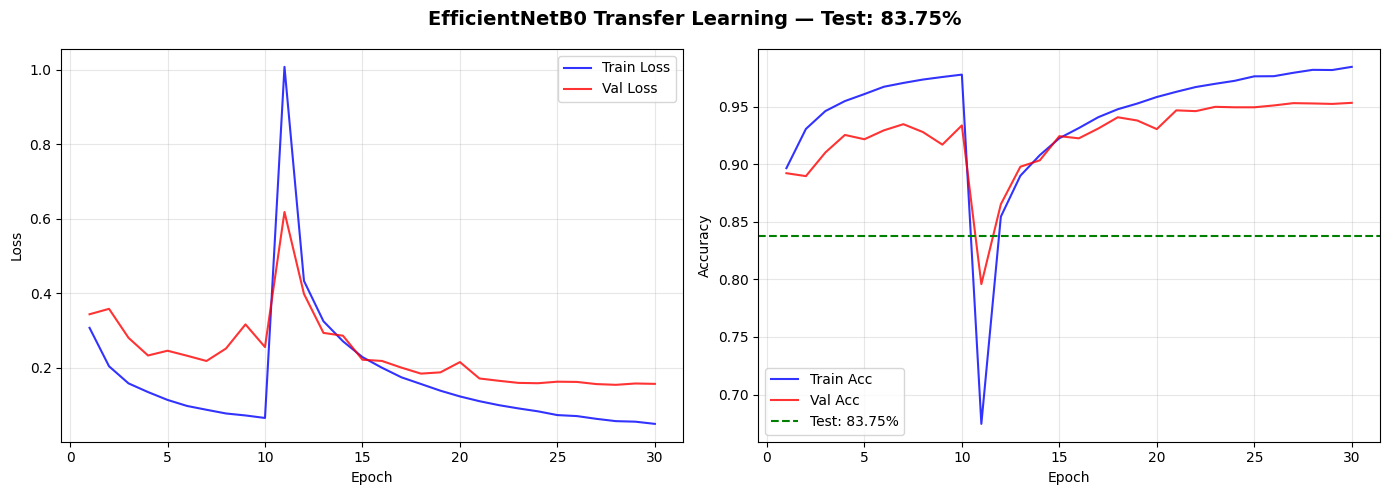

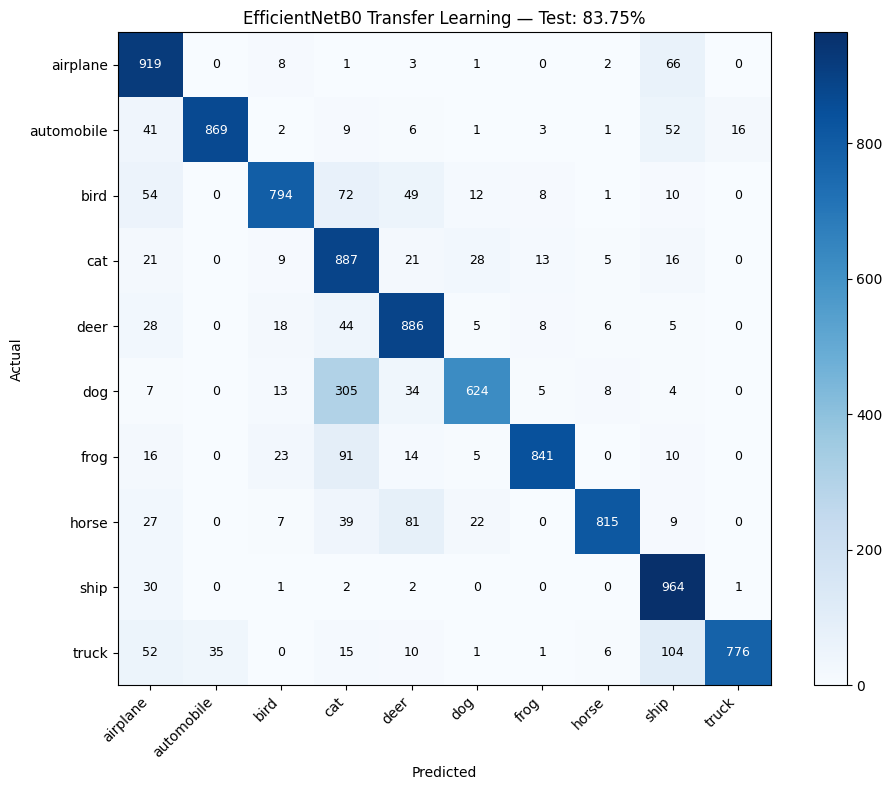

In [11]:
effnet_model = keras.models.load_model(os.path.join(model_dir, 'best_effnet_finetuned.h5'))

print('=== EfficientNetB0 Test Results ===')
eff_pred, eff_true, eff_test_acc = evaluate_model(
    effnet_model, test_ds_eff, y_test, label_names
)

eff_history = merge_histories(eff_history_head.history, eff_history_ft.history)
plot_results(eff_history, eff_pred, eff_true, eff_test_acc,
             label_names, 'EfficientNetB0 Transfer Learning', 'efficientnet')

---
# Final Comparison: All Models

In [22]:
print('=' * 60)
print('FINAL COMPARISON (TensorFlow)')
print('=' * 60)
print(f'{"Model":<30s} {"Test Acc":>10s}')
print('-' * 45)
print(f'{"Custom CNN (32x32)":<30s} {cnn_test_acc*100:>9.2f}%')
print(f'{"ResNet50V2 (pretrained)":<30s} {resnet_test_acc*100:>9.2f}%')
print(f'{"EfficientNetB0 (pretrained)":<30s} {eff_test_acc*100:>9.2f}%')
print('=' * 60)

FINAL COMPARISON (TensorFlow)
Model                            Test Acc
---------------------------------------------
Custom CNN (32x32)                 86.89%
ResNet50V2 (pretrained)            94.30%
EfficientNetB0 (pretrained)        83.75%


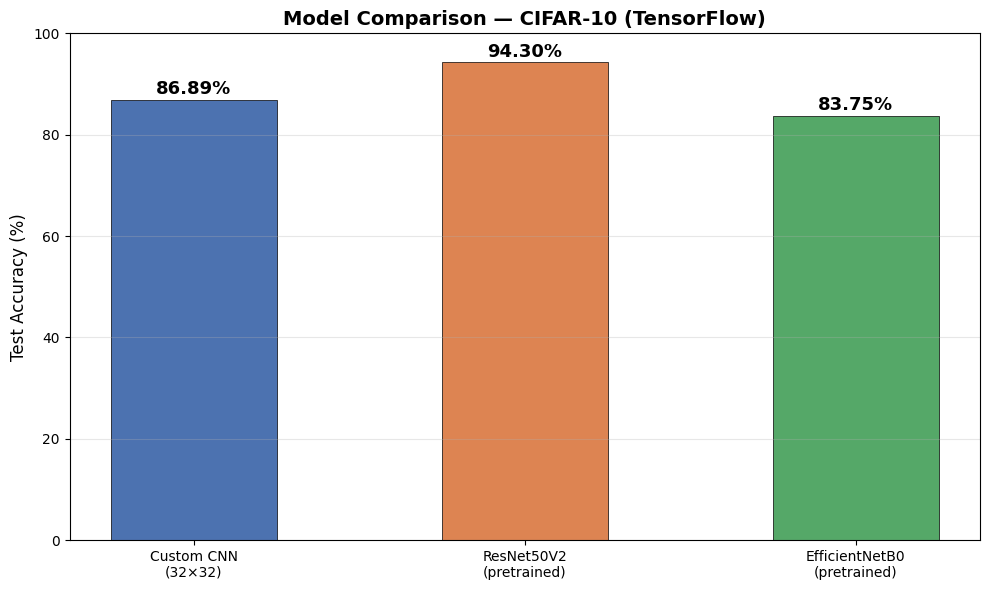

In [25]:
models_names = ['Custom CNN\n(32×32)', 'ResNet50V2\n(pretrained)', 'EfficientNetB0\n(pretrained)']
accuracies = [cnn_test_acc * 100, resnet_test_acc * 100, eff_test_acc * 100]
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models_names, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — CIFAR-10 (TensorFlow)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir, 'model_comparison.png'), dpi=150)
plt.show()

## Summary

| Phase | Model | Strategy | Epochs |
|---|---|---|---|
| 1 | Custom CNN | Train from scratch (see CNN notebook) | 100 |
| **2** | **ResNet50V2** | Freeze → Train head → Unfreeze → Fine-tune | 10 + 20 |
| **3** | **EfficientNetB0** | Freeze → Train head → Unfreeze → Fine-tune | 10 + 20 |

### Key Techniques Used
| Technique | Purpose |
|---|---|
| Transfer Learning | Reuse ImageNet features instead of learning from scratch |
| Freeze + Unfreeze | Prevent destroying pretrained weights early on |
| Keras preprocess_input | Match the normalization pretrained models were trained with |
| SGD + Momentum | Better generalization than Adam for fine-tuning |
| tf.data Pipeline | Efficient on-the-fly resize 32×32 → 224×224 |
| EarlyStopping | Prevent overfitting with patience-based stopping |
| ModelCheckpoint | Save best model weights automatically |